# 🧪 Lab 02: Otimizadores Avançados (Adam) e Regularização (Dropout) em NumPy
**Módulo:** `02-deep-learning / neural-networks-from-scratch`

## Objetivos
1. Implementar a técnica de **Inverted Dropout** do zero para evitar overfitting.
2. Implementar o otimizador **Adam (Adaptive Moment Estimation)** do zero em NumPy.
3. Comparar a taxa de convergência entre o **SGD tradicional** e o **Adam**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Implementação do Inverted Dropout

In [2]:
def apply_dropout(A, keep_prob=0.8, is_training=True):
    """
    Aplica Inverted Dropout para manter a escala das ativações constante durante o treino.
    """
    if not is_training or keep_prob >= 1.0:
        return A, None
    
    # Máscara binária onde 1 significa manter o neurónio
    mask = (np.random.rand(*A.shape) < keep_prob) / keep_prob
    A_drop = A * mask
    return A_drop, mask

# Teste rápido de Dropout
A_exemplo = np.ones((1, 10))
A_dropped, mask = apply_dropout(A_exemplo, keep_prob=0.7, is_training=True)

print("Ativações Originais :", A_exemplo)
print("Após Dropout (70%)  :", A_dropped)

Ativações Originais : [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Após Dropout (70%)  : [[0.         0.         1.42857143 1.42857143 1.42857143 1.42857143
  1.42857143 1.42857143 0.         0.        ]]


## 2. Implementação do Otimizador Adam do Zero

In [3]:
class AdamOptimizer:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        
        # Inicializa o 1º momento (m) e 2º momento (v) para cada parâmetro
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}

    def update(self, params, grads):
        self.t += 1
        for k in params.keys():
            # Atualização dos momentos
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (grads[k] ** 2)
            
            # Correção de viés (Bias Correction)
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            
            # Atualização dos parâmetros
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

print("✅ Otimizador Adam pronto a ser utilizado!")

✅ Otimizador Adam pronto a ser utilizado!


## 3. Comparação de Convergência: SGD vs. Adam

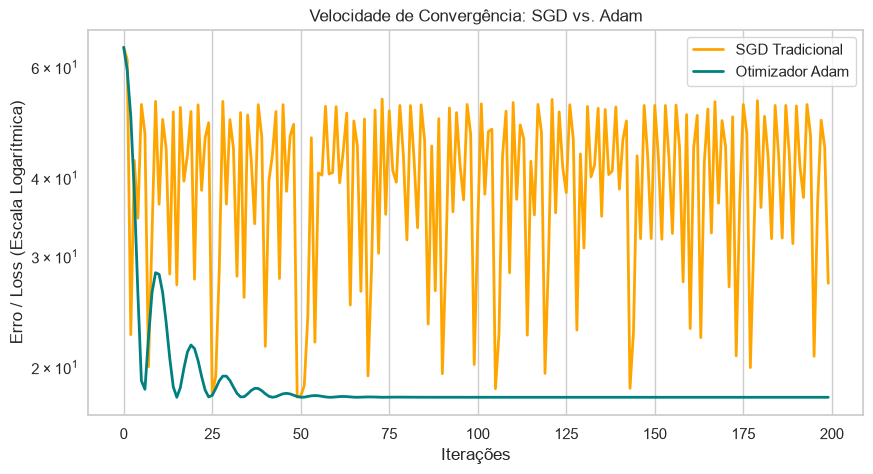

In [4]:
# Otimização da função de Rastrigin (problema de regressão/otimização não-convexa)
def loss_func(W):
    return W[0]**2 + W[1]**2 - 10 * np.cos(2 * np.pi * W[0]) - 10 * np.cos(2 * np.pi * W[1]) + 20

def grad_func(W):
    dW0 = 2 * W[0] + 20 * np.pi * np.sin(2 * np.pi * W[0])
    dW1 = 2 * W[1] + 20 * np.pi * np.sin(2 * np.pi * W[1])
    return np.array([dW0, dW1])

# Treino com SGD
W_sgd = np.array([3.5, 3.5])
history_sgd = []
lr_sgd = 0.01

for _ in range(200):
    loss = loss_func(W_sgd)
    history_sgd.append(loss)
    grad = grad_func(W_sgd)
    W_sgd -= lr_sgd * grad

# Treino com Adam
W_adam = np.array([3.5, 3.5])
params_adam = {'W': W_adam}
adam = AdamOptimizer(params_adam, lr=0.1)
history_adam = []

for _ in range(200):
    loss = loss_func(params_adam['W'])
    history_adam.append(loss)
    grad = grad_func(params_adam['W'])
    adam.update(params_adam, {'W': grad})

# Gráfico comparativo
plt.plot(history_sgd, label='SGD Tradicional', color='orange', lw=2)
plt.plot(history_adam, label='Otimizador Adam', color='teal', lw=2)
plt.yscale('log')
plt.title('Velocidade de Convergência: SGD vs. Adam')
plt.xlabel('Iterações')
plt.ylabel('Erro / Loss (Escala Logarítmica)')
plt.legend()
plt.show()